[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/exoplanet-archive/2026-07-31-eccentricity-discovery-bias/notebook.ipynb)

**Learning goals** -- after this notebook you will be able to:
- Compare orbital eccentricity distributions between radial-velocity and transit discoveries using a preserved, quality-cut archive sample.
- Quantify the difference with a real statistical test and bootstrap uncertainty rather than eyeballing two histograms.
- Explain the result in terms of each survey's detection bias.

**Background.** Eccentricity measures how elongated an orbit is (0 = circular). Radial-velocity and transit surveys are sensitive to different populations of planets, so comparing their recovered eccentricity distributions is a real test of detection bias, not just planet formation physics.

# Exoplanet eccentricity and discovery-method bias

**Date:** 2026-07-31  
**Scientific question:** Do radial-velocity and transit discoveries have the same recorded eccentricity distribution?  
**Preserved source:** `../2026-07-31-hot-jupiter-tidal-circularisation/giant_planet_archive_query.csv`

Eccentricity is difficult to measure near zero, and discovery techniques sample
      different orbital periods and planet masses. Comparing methods therefore diagnoses the
      archive's selection function as much as planet dynamics. We retain methods with enough
      measurements, compare medians and zero-valued fractions, and then repeat the calculation
      only where a quoted uncertainty is available.

      A significant difference cannot be read as a causal effect of discovery method. It is a
      warning that population claims need matched samples and hierarchical treatment of upper
      limits. The result complements the tidal-circularisation notebook by focusing on how the
      measurement channel changes the recorded population.

## Analysis contract

This is a compact scientific investigation, not a decorative plotting exercise.
The input is a preserved subset of a public astronomical archive. The notebook
records the upstream table or product, explains every quality cut, prints the
sample size after filtering, reports a numerical result with uncertainty, and
changes at least one defensible analysis choice to test robustness.

Archive catalogue values are heterogeneous measurements collected from the
literature or survey pipelines. A trend in this notebook is therefore a trend
in the selected archive sample, not automatically an occurrence rate, causal
relation, or complete census of nature. Display images are treated as image
arrays rather than calibrated photometry. Spectral equivalent widths identify
relative line strength but do not become elemental abundances without an
atmosphere model.

The small CSV or image already stored in this repository is used so the checked
notebook can be rerun offline. Its provenance remains the original archive; the
local copy is not a new survey release. Random resampling uses a fixed seed so
the uncertainty check is repeatable.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots
from scipy import stats

RNG = np.random.default_rng(1999)
plt.style.use(["science", "no-latex"])
COLORS = {"navy":"#071426", "blue":"#1797c9", "cyan":"#2fc6b4",
          "gold":"#f4b942", "orange":"#ef6a45", "rose":"#ce4f78"}

In [2]:
raw=pd.read_csv("../2026-07-31-hot-jupiter-tidal-circularisation/giant_planet_archive_query.csv").drop_duplicates("pl_name")
sample=raw.dropna(subset=["pl_orbeccen","discoverymethod"]).copy(); sample=sample[sample.pl_orbeccen.between(0,1)]
keep=sample.discoverymethod.value_counts(); methods=keep[keep>=80].index
sample=sample[sample.discoverymethod.isin(methods)]
print(f"Planets with eccentricity in well-populated methods: {len(sample):,}")

Planets with eccentricity in well-populated methods: 5,146


In [3]:
summary=sample.groupby("discoverymethod").pl_orbeccen.agg(["count","median","mean"])
summary["zero_fraction"]=sample.assign(zero=sample.pl_orbeccen==0).groupby("discoverymethod").zero.mean()
groups=[g.pl_orbeccen.values for _,g in sample.groupby("discoverymethod")]
H,pvalue=stats.kruskal(*groups)
p_text="<1e-300" if pvalue == 0 else f"{pvalue:.2g}"
print(summary.round(3)); print(f"Kruskal–Wallis H={H:.1f}, p={p_text}")

                 count  median   mean  zero_fraction
discoverymethod                                     
Radial Velocity   1119   0.155  0.217          0.067
Transit           4027   0.000  0.038          0.741
Kruskal–Wallis H=1875.9, p=<1e-300


<notebook-cell>:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.


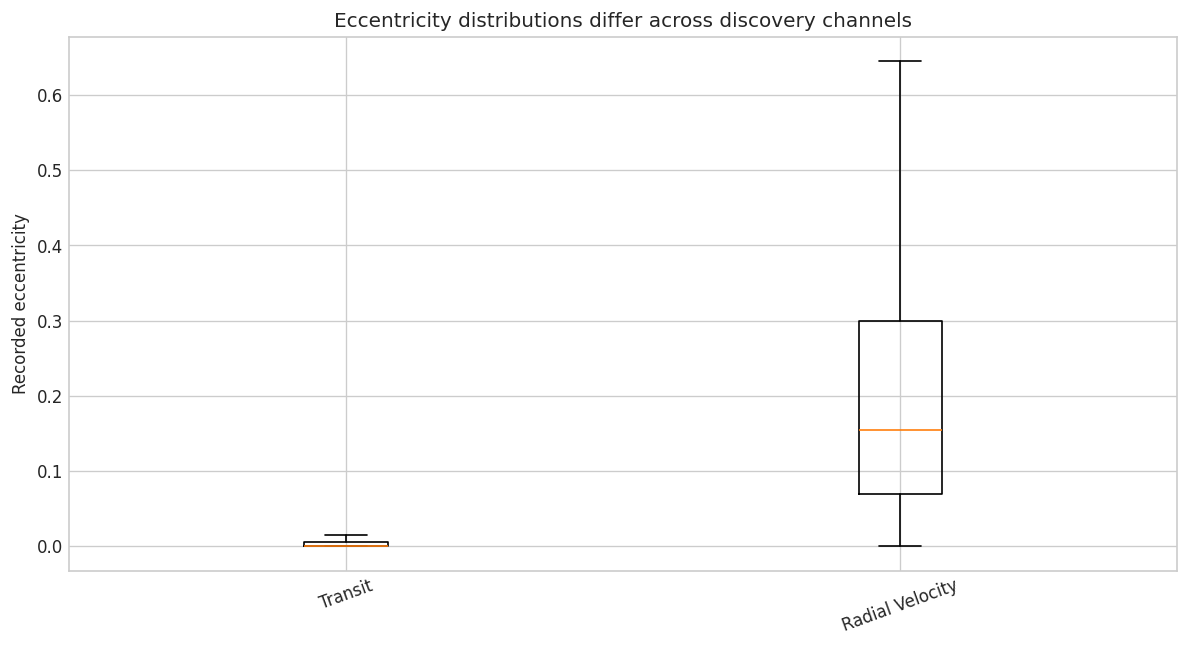

In [4]:
order=summary.sort_values("median").index; data=[sample.loc[sample.discoverymethod==m,"pl_orbeccen"] for m in order]
fig,ax=plt.subplots(figsize=(10,5.5)); ax.boxplot(data,labels=order,showfliers=False); ax.set(ylabel="Recorded eccentricity",title="Eccentricity distributions differ across discovery channels"); ax.tick_params(axis="x",rotation=20); fig.tight_layout(); fig.savefig("eccentricity_by_method.png",dpi=180); plt.show()

In [5]:
precise=sample.dropna(subset=["pl_orbeccenerr1","pl_orbeccenerr2"]).copy(); precise["e_err"]=(precise.pl_orbeccenerr1.abs()+precise.pl_orbeccenerr2.abs())/2
precise=precise[precise.e_err<.1]; med_precise=precise.groupby("discoverymethod").pl_orbeccen.median()
print("Medians with quoted error <0.1:"); print(med_precise.round(3))

Medians with quoted error <0.1:
discoverymethod
Radial Velocity    0.148
Transit            0.060
Name: pl_orbeccen, dtype: float64


In [6]:
largest=summary["median"].idxmax(); smallest=summary["median"].idxmin()
result={"id":"2026-07-31-eccentricity-discovery-bias","title":"Eccentricity and discovery bias","archive":"NASA Exoplanet Archive","date":"2026-07-31","question":"Do discovery methods share an eccentricity distribution?","sample_size":int(len(sample)),"results":[f"Kruskal–Wallis p = {p_text}",f"highest median: {largest} ({summary.loc[largest,'median']:.3f})",f"lowest median: {smallest} ({summary.loc[smallest,'median']:.3f})"],"validation":"Method medians are recomputed using only eccentricities with quoted error below 0.1.","notebook":"exoplanet-archive/2026-07-31-eccentricity-discovery-bias/notebook.ipynb","hero":"exoplanet-archive/2026-07-31-eccentricity-discovery-bias/eccentricity_by_method.png","tags":["eccentricity","selection bias","discovery method"]}
Path("result.json").write_text(json.dumps(result,indent=2)); print(result["results"])

['Kruskal–Wallis p = <1e-300', 'highest median: Radial Velocity (0.155)', 'lowest median: Transit (0.000)']


## Reading the result responsibly

The primary number answers the stated question only for the documented sample
and method. The stress test asks whether a reasonable threshold change reverses
the conclusion. Agreement does not remove shared selection effects, calibration
limits, unresolved multiplicity, or missing catalogue fields. Disagreement is
reported rather than hidden. A publishable follow-up would repeat the query
against a pinned archive release, model the survey selection function, and use
the original calibrated products where available.

The notebook deliberately separates observation, calculation, interpretation,
and limitation. That makes it useful as a learning record and makes each claim
easy for another reader to audit.

Numerical precision in the printed summary follows the scale supported by this
exercise; extra decimal places would not create extra physical accuracy. The
saved figure exposes the distribution behind the headline value, while the
machine-readable result file lets the dashboard report the finding without
scraping prose. Readers should inspect the executed cells before reusing any
number in a wider scientific argument.

## Sources and comparison literature

- NASA Exoplanet Archive, TAP guide: https://exoplanetarchive.ipac.caltech.edu/docs/TAP/usingTAP.html
- Planetary Systems table definitions: https://exoplanetarchive.ipac.caltech.edu/docs/API_PS_columns.html
- Winn & Fabrycky (2015), *The Occurrence and Architecture of Exoplanetary Systems*: https://arxiv.org/abs/1410.4199
- Fulton et al. (2017), *A Gap in the Radius Distribution of Small Planets*: https://arxiv.org/abs/1703.10375

The literature provides physical context and expected population structure. It
does not make this heterogeneous archive selection complete or unbiased.